# Quantify junction diversity
## Within junction distance
Create distance matrix between isolates based on pangraph of one junction. Consider the following distances:
- jaccard index of shared sequence length
- jaccard index of shared blogs (problem: don't take into account long deletions that could just have been one event)
- jaccard index of shared edges (problem: sequences might have shared blogs but completely different edges)
- number of divergence points in paths, solve by getting longest common subsequence (Needleman-Wunsch) (doesn't consider movement of blogs)


In [1]:
# set working directory to project folder
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import altair as alt
import numpy as np
import pypangraph as pp
from Bio import Phylo, SeqIO, pairwise2
from Bio import Align

from junction_analysis.diversity_metrics import compare_sequences_by_shared_proportion, calculate_block_ji_matrix, calculate_edge_ji_matrix, calculate_divergence_matrix, compute_diversity_all_junctions, calculate_dedup_block_ji_matrix, calculate_dedup_edge_ji_matrix, compute_dedup_ji_all_junctions
from junction_analysis.plotting import plot_heatmap_hover
from junction_analysis.consensus import make_deduplicated_paths

/opt/homebrew/Caskroom/miniforge/base/envs/junctions/lib/python3.13/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [2]:
example_junction = "CIRMBUYJFK_f__CWCCKOQCWZ_r"
example_pangraph = pp.Pangraph.from_json(f"../results/junction_pangraphs/{example_junction}.json")

block_df = calculate_dedup_block_ji_matrix(example_pangraph)
edge_df = calculate_dedup_edge_ji_matrix(example_pangraph)

In [3]:
pairwise_df = compute_dedup_ji_all_junctions(                                                                                                                                                             
      pangraph_dir="../results/junction_pangraphs",                                                                                                                                                       
      save_path="../results/consensus_analysis/pairwise_dedup_ji.csv",                                                                                                                                      
  )

Saved to ../results/consensus_analysis/pairwise_dedup_ji.csv


In [5]:
pairwise_df[pairwise_df['junction_name'] == 'CIRMBUYJFK_f__CWCCKOQCWZ_r']

,junction_name,isolate_1,isolate_2,block_ji_dist,edge_ji_dist
2672333,CIRMBUYJFK_f__CWCCKOQCWZ_r,NC_022648.1,NZ_AP018784.1,1.000000,1.000000
2672334,CIRMBUYJFK_f__CWCCKOQCWZ_r,NC_022648.1,NZ_AP021998.1,1.000000,1.000000
2672335,CIRMBUYJFK_f__CWCCKOQCWZ_r,NC_022648.1,NZ_AP022032.1,1.000000,1.000000
2672336,CIRMBUYJFK_f__CWCCKOQCWZ_r,NC_022648.1,NZ_AP022044.1,0.852941,0.742857
2672337,CIRMBUYJFK_f__CWCCKOQCWZ_r,NC_022648.1,NZ_AP022064.1,1.000000,1.000000
...,...,...,...,...,...
2696859,CIRMBUYJFK_f__CWCCKOQCWZ_r,NZ_OX637959.1,NZ_OX637964.1,0.312500,0.250000
2696860,CIRMBUYJFK_f__CWCCKOQCWZ_r,NZ_OX637959.1,NZ_OY019088.1,0.312500,0.250000
2696861,CIRMBUYJFK_f__CWCCKOQCWZ_r,NZ_OX637961.1,NZ_OX637964.1,0.312500,0.250000
2696862,CIRMBUYJFK_f__CWCCKOQCWZ_r,NZ_OX637961.1,NZ_OY019088.1,0.312500,0.250000


In [7]:
pangraph = pp.Pangraph.from_json(f"../results/junction_pangraphs/ADIVNXMSJF_f__SKCSCYCISB_f.json")
make_deduplicated_paths(pangraph)

({'NZ_CP063774.1': [10026712397854510732|+|],
  'NZ_LS992180.1': [10026712397854510732|+|],
  'NZ_LS992168.1': [10026712397854510732|+|],
  'NZ_CP021207.1': [10026712397854510732|+|],
  'NZ_CP103465.1': [10026712397854510732|+|],
  'NZ_CP116145.1': [10026712397854510732|+|],
  'NZ_CP124436.1': [10026712397854510732|+|],
  'NZ_CP107162.1': [10026712397854510732|+|],
  'NZ_AP026794.1': [10026712397854510732|+|],
  'NZ_CP124322.1': [10026712397854510732|+|],
  'NZ_CP124487.1': [10026712397854510732|+|],
  'NZ_CP124498.1': [10026712397854510732|+|],
  'NZ_CP015069.1': [10026712397854510732|+|],
  'NZ_CP018979.1': [10026712397854510732|+|],
  'NZ_CP014497.1': [10026712397854510732|+|],
  'NZ_AP022362.1': [10026712397854510732|+|],
  'NZ_CP069488.1': [10026712397854510732|+|],
  'NZ_CP124471.1': [10026712397854510732|+|],
  'NZ_CP115390.1': [10026712397854510732|+|],
  'NZ_CP124324.1': [10026712397854510732|+|],
  'NZ_OW849064.1': [10026712397854510732|+|],
  'NZ_CP014316.1': [10026712397854

In [5]:
summary_df, pairwise_df = compute_diversity_all_junctions(  
    pangraph_dir="../results/junction_pangraphs",
    metrics=["dedup_block_ji", "dedup_edge_ji"],   # optional subset                                                                                                                                                  
    save_path="../results/consensus_analysis/mean_diversity_per_junction_ji.csv",                                                                                                                                                                                    
    pairwise_save_path="../results/consensus_analysis/pairwise_diversity_per_junction_ji.csv",                                                                                                                                                                             
)

  ADIVNXMSJF_f__SKCSCYCISB_f [dedup_block_ji]: cannot access local variable 'mat' where it is not associated with a value
  ADIVNXMSJF_f__SKCSCYCISB_f [dedup_edge_ji]: cannot access local variable 'mat' where it is not associated with a value
Saved diversity summary to ../results/consensus_analysis/mean_diversity_per_junction_ji.csv
Saved pairwise distances to ../results/consensus_analysis/pairwise_diversity_per_junction_ji.csv


In [ ]:
pairwise_df = pd.read_csv('../results/consensus_analysis/pairwise_diversity_per_junction_ji.csv')

np.int64(6560110)

In [10]:
summary_df

,junction_name,mean_dedup_block_ji,mean_dedup_edge_ji
0,ADIVNXMSJF_f__SKCSCYCISB_f,NaN,NaN
1,ADIVNXMSJF_r__CGRLRHSCCE_f,NaN,NaN
2,ADOVFNSINA_f__ECOWCWQMQJ_f,NaN,NaN
3,ADOVFNSINA_r__CAPUVXKIHV_r,NaN,NaN
4,AEJQYPEVQR_f__SQYOENFQOY_f,NaN,NaN
...,...,...,...
543,XXVQEZNBQB_f__YMBQLXNBIS_f,NaN,NaN
544,YJSEGEHASG_r__YWSGZOAHNX_r,NaN,NaN
545,YUOECYBHUS_f__ZTHKZYHPIX_f,NaN,NaN
546,YVEVUPDYEE_f__ZFYFAGFPQE_f,NaN,NaN


In [8]:
pairwise_df[pairwise_df['junction_name'] == 'CIRMBUYJFK_f__CWCCKOQCWZ_r']

KeyError: 'junction_name'

In [5]:
pairwise_df.block_ji.value_counts()

block_ji
1.000000    12052367
0.666667      240835
0.500000       98149
0.750000       71846
0.800000       61730
              ...   
0.192661           1
0.437956           1
0.330000           1
0.455224           1
0.343023           1
Name: count, Length: 3847, dtype: int64

In [6]:
_fname = f"../config/junction_stats.csv"
jdf = pd.read_csv(_fname)
jdf

,edge,n_iso,n_blocks,has_dupl,n_categories,majority_category,singleton,cat_entropy,n_nodes,min_length,max_length,mean_length,n_all_cores,core_left_length,core_right_length,transitive,nonempty_acc_len,nonempty_freq
0,HUTOPWFGVH_f__WJBYSSJHSE_f,222,5,False,3,218,False,0.100354,11,18176,18953,18189.108108,218,16280.0,1698.0,False,727.5,0.018018
1,IZQZNHJQRQ_f__ZVPGGEJIIF_f,222,3,False,2,221,True,0.028831,5,11739,12516,11742.500000,221,1529.0,10210.0,False,777.0,0.004505
2,JNLRGIQXOF_f__YQUHGDANHE_f,222,3,False,2,221,True,0.028831,5,27949,29386,27955.472973,221,23708.0,4241.0,False,1437.0,0.004505
3,JMOMDSHCBS_r__SPDPCYMYDN_r,222,3,False,2,220,False,0.051397,5,7364,8141,7371.000000,220,2780.0,4584.0,False,777.0,0.009009
4,JKRDVEYDGL_f__OTPJRRWJRK_f,222,3,False,2,221,True,0.028831,5,10056,48231,10227.959459,221,7295.0,2761.0,False,38175.0,0.004505
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
543,GPXHVRRZLC_f__KYQOKYBCOW_f,2,8,False,2,1,True,0.693147,12,65779,105312,85545.500000,0,18605.0,29023.0,False,35067.5,1.000000
544,EOBHADSLFU_f__SKPHAXSFLS_r,2,1,False,1,2,False,0.000000,1,7230,7230,7230.000000,2,7230.0,7230.0,True,NaN,0.000000
545,XXIWNZXZTK_f__ZLAJFQLBFQ_r,2,3,False,2,1,True,0.693147,6,83629,83629,83629.000000,2,31644.0,48920.0,False,NaN,0.000000
546,YUOECYBHUS_f__ZTHKZYHPIX_f,2,20,True,2,1,True,0.693147,35,66709,186025,126367.000000,0,60231.0,5710.0,False,60426.0,1.000000


In [3]:
#example_junction = jdf.iloc[0].edge
#example_junction = "ATPWUNKKID_f__KKPYPKGMXA_f"
example_junction = "CIRMBUYJFK_f__CWCCKOQCWZ_r"
example_pangraph = pp.Pangraph.from_json(f"../results/junction_pangraphs/{example_junction}.json")
example_pangraph.to_blockstats_df()

,count,n_strains,duplicated,core,len
block_id,,,,,
185719230501067033,4,4,False,False,4204
517157241956952768,7,7,False,False,1248
693804415432571803,170,170,False,False,4736
913783977968963568,168,168,False,False,133
964531385716605116,13,13,False,False,1239
1314867519434933921,169,169,False,False,1920
1708810210093552769,221,221,False,False,2589
2278011600046483881,1,1,False,False,37622
3035246746052306249,169,169,False,False,7212


### Shared sequence length

In [4]:
sequence_comparison_df = example_pangraph.pairwise_accessory_genome_comparison()
jaccard_sequences_df, diff, shared = compare_sequences_by_shared_proportion(sequence_comparison_df, order = "hierarchical")
plot_heatmap_hover(jaccard_sequences_df, diff, shared, show_tick_labels=False, similarity_measure="shared_proportion")

### Shared blocks

In [5]:
jaccard_blocks_df, diff, shared = calculate_block_ji_matrix(example_pangraph, order="hierarchical")
plot_heatmap_hover(jaccard_blocks_df, diff, shared, show_tick_labels=False, similarity_measure="shared_blocks")

### Shared edges

In [6]:
jaccard_edges_df, diff, shared = calculate_edge_ji_matrix(example_pangraph, order="hierarchical")
plot_heatmap_hover(jaccard_edges_df, diff, shared, show_tick_labels=False, similarity_measure="shared_edges")

### Number of divergence points betwenn paths

In [7]:
divergence_points_mat = calculate_divergence_matrix(example_pangraph, order="hierarchical")
plot_heatmap_hover(divergence_points_mat, show_tick_labels=False, similarity_measure="divergence_points")

/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/junction_analysis/helpers.py:30: ClusterWarning:

The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix



## Metric comparison
Scatter plots comparing the difference metrices with each other

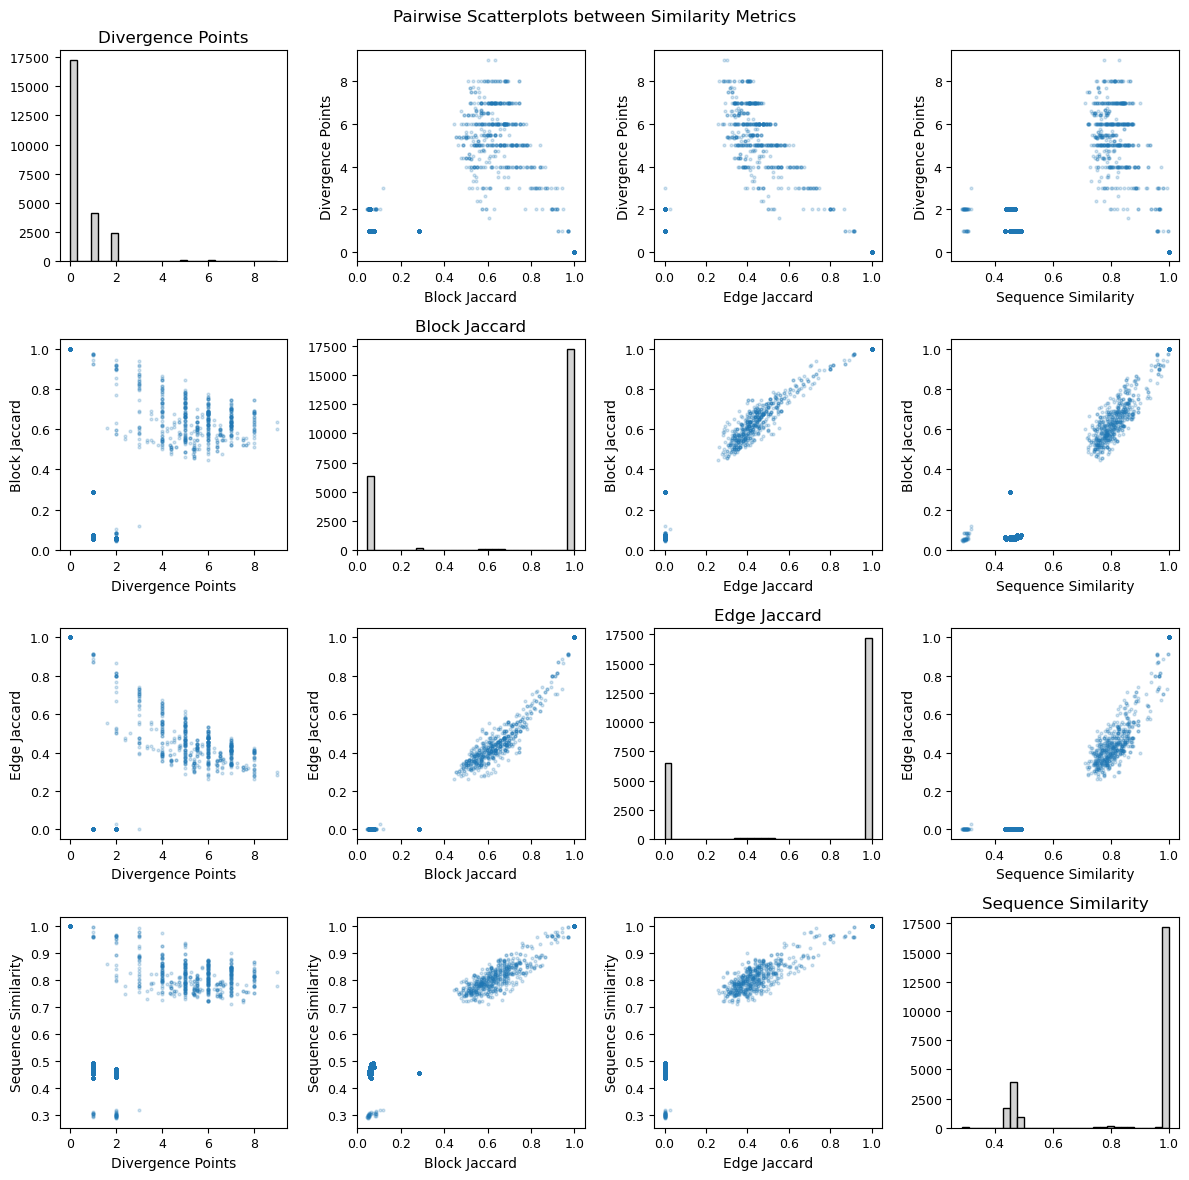

In [5]:
def plot_similarity_scatter(matrices, labels=None, figsize=(10, 10)):
    """
    Plot pairwise scatterplots between multiple similarity matrices.
    
    Parameters
    ----------
    matrices : list of pd.DataFrame
        List of symmetric similarity matrices (same index and columns).
    labels : list of str, optional
        Labels for each matrix. If None, generic labels are used.
    figsize : tuple
        Figure size.
    """
    n = len(matrices)
    if labels is None:
        labels = [f"Metric {i+1}" for i in range(n)]

    ref_order = matrices[0].index
    matrices = [m.loc[ref_order, ref_order] for m in matrices]

    def flatten_upper(df):
        vals = df.values
        iu = np.triu_indices_from(vals, k=1)
        return vals[iu]

    flat_vals = [flatten_upper(m) for m in matrices]

    fig, axes = plt.subplots(n, n, figsize=figsize)

    for i in range(n):
        for j in range(n):
            ax = axes[i, j]

            if i == j:
                # Diagonal: show histogram and label
                ax.hist(flat_vals[i], bins=30, color='lightgray', edgecolor='black')
                ax.set_title(labels[i], fontsize=12)
            else:
                ax.scatter(flat_vals[j], flat_vals[i], s=4, alpha=0.2)
                ax.set_xlabel(labels[j], fontsize=10)
                ax.set_ylabel(labels[i], fontsize=10)

            # Make ticks smaller but visible
            ax.tick_params(axis='both', which='major', labelsize=9)

    fig.suptitle("Pairwise Scatterplots between Similarity Metrics", fontsize=12)
    fig.tight_layout()
    plt.show()

plot_similarity_scatter([divergence_points_mat, jaccard_blocks_df, jaccard_edges_df, jaccard_sequences_df], labels=["Divergence Points", "Block Jaccard", "Edge Jaccard", "Sequence Similarity"], figsize=(12,12))

## Pipeline for one junction

/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/junction_analysis/helpers.py:30: ClusterWarning:

The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix



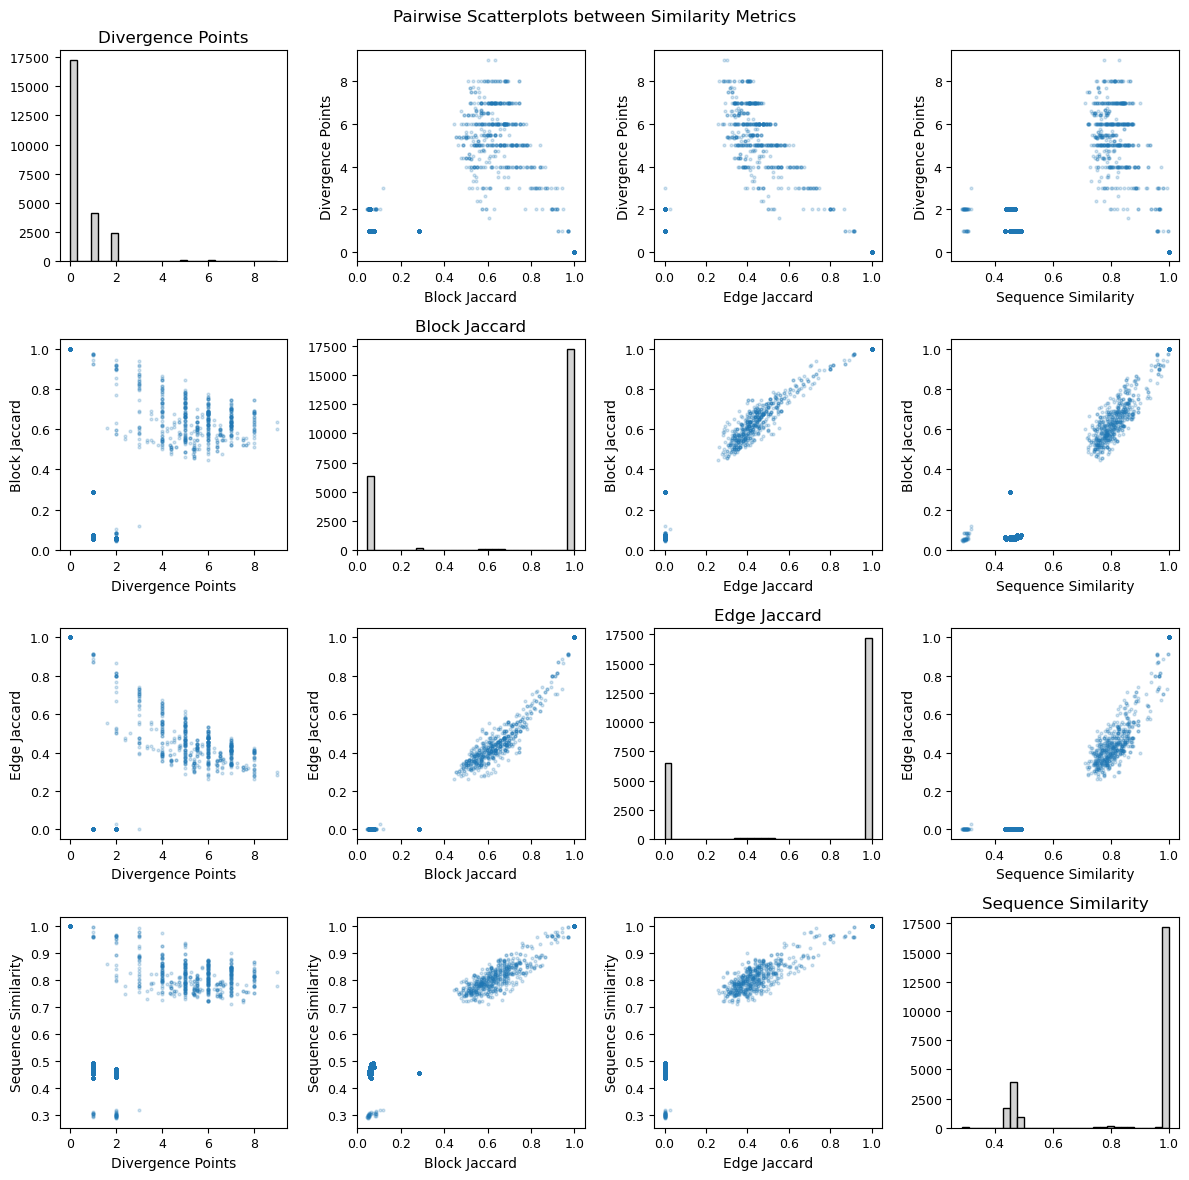

In [6]:
example_junction = "ATPWUNKKID_f__KKPYPKGMXA_f"
example_pangraph = pp.Pangraph.from_json(f"../results/junction_pangraphs/{example_junction}.json")
example_pangraph.to_blockstats_df()

sequence_comparison_df = example_pangraph.pairwise_accessory_genome_comparison()
jaccard_sequences_df, diff, shared = compare_sequences_by_shared_proportion(sequence_comparison_df, order = "hierarchical")
plot_heatmap_hover(jaccard_sequences_df, diff, shared, show_tick_labels=False, similarity_measure="shared_proportion")

jaccard_blocks_df, diff, shared = calculate_block_ji_matrix(example_pangraph, order="hierarchical")
plot_heatmap_hover(jaccard_blocks_df, diff, shared, show_tick_labels=False, similarity_measure="shared_blocks")

jaccard_edges_df, diff, shared = calculate_edge_ji_matrix(example_pangraph, order="hierarchical")
plot_heatmap_hover(jaccard_edges_df, diff, shared, show_tick_labels=False, similarity_measure="shared_edges")

divergence_points_mat = calculate_divergence_matrix(example_pangraph, order="hierarchical")
plot_heatmap_hover(divergence_points_mat, show_tick_labels=False, similarity_measure="divergence_points")

plot_similarity_scatter([divergence_points_mat, jaccard_blocks_df, jaccard_edges_df, jaccard_sequences_df], labels=["Divergence Points", "Block Jaccard", "Edge Jaccard", "Sequence Similarity"], figsize=(12,12))

In [7]:
sequence_comparison_df

shared   diff  similarity
path_i        path_j                                  
NZ_CP023844.1 NZ_CP023844.1   28040      0    1.000000
              NZ_CP124511.1   28040      0    1.000000
NZ_CP124511.1 NZ_CP023844.1   28040      0    1.000000
NZ_CP023844.1 NZ_OW849064.1   28040      0    1.000000
NZ_OW849064.1 NZ_CP023844.1   28040      0    1.000000
...                             ...    ...         ...
NZ_CP115324.1 NZ_CP051663.1   28040      0    1.000000
NZ_CP107151.1 NZ_CP107151.1   63931      0    1.000000
              NZ_CP115324.1   28040  35891    0.438598
NZ_CP115324.1 NZ_CP107151.1   28040  35891    0.438598
              NZ_CP115324.1   28040      0    1.000000

[48841 rows x 3 columns]

In [9]:
divergence_points_mat

,NZ_CP021179.1,NZ_OY019088.1,NZ_OX637961.1,NZ_OX637959.1,NZ_OX030701.1,NZ_OW968277.1,NZ_OW849064.1,NZ_OW848785.1,NZ_LS999560.1,NZ_LS992192.1,...,NZ_CP072980.1,NZ_CP023826.1,NZ_CP030337.1,NZ_CP036245.1,NZ_CP107128.1,NZ_OX637964.1,NZ_CP107122.1,NZ_CP107151.1,NZ_CP089445.1,NZ_CP107162.1
NZ_CP021179.1,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
NZ_OY019088.1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
NZ_OX637961.1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
NZ_OX637959.1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
NZ_OX030701.1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NZ_OX637964.1,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,3.0,3.0,3.0,4.0,1.0,0.0,4.0,3.0,3.0,4.0
NZ_CP107122.1,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,6.0,6.0,6.0,7.0,4.0,4.0,0.0,3.0,1.0,2.0
NZ_CP107151.1,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,5.0,5.0,5.0,7.0,3.0,3.0,3.0,0.0,2.0,2.0
NZ_CP089445.1,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,5.0,5.0,5.0,6.0,3.0,3.0,1.0,2.0,0.0,1.0


In [2]:
ji_df = compute_diversity_all_junctions(                                                                                                                                                                    
  pangraph_dir="../results/junction_pangraphs",                                                                                                                                                         
  save_path="../results/consensus_analysis/mean_diversity_per_junction.csv",
)

  EJPOGALASQ_f__KUIFCLFQSI_r [mean_n_divergence_points]: Too many unique blocks (141); only 129 symbols defined.
  IHKFSQQUKE_r__KPBYGJHRZJ_f [mean_n_divergence_points]: Too many unique blocks (214); only 129 symbols defined.
  JVNRLCFAVD_f__PLTCZQCVRD_r [mean_n_divergence_points]: Too many unique blocks (254); only 129 symbols defined.
  KAIPBNCIHR_r__WXCHSHHCDT_f [mean_n_divergence_points]: Too many unique blocks (149); only 129 symbols defined.
  RKAOKULCFF_f__VFXLTFSKTV_r [mean_n_divergence_points]: Too many unique blocks (136); only 129 symbols defined.
  RYYAQMEJGY_r__ZTHKZYHPIX_f [mean_n_divergence_points]: Too many unique blocks (177); only 129 symbols defined.
  VZTFXIZVXB_f__YOCIMVGHSL_f [mean_n_divergence_points]: Too many unique blocks (146); only 129 symbols defined.
  XXVMWZCEKI_r__YUOECYBHUS_r [mean_n_divergence_points]: Too many unique blocks (323); only 129 symbols defined.
Saved diversity summary to ../results/consensus_analysis/mean_diversity_per_junction.csv


In [3]:
ji_df

,junction_name,mean_block_ji,mean_edge_ji,mean_seq_similarity,mean_n_divergence_points
0,ADIVNXMSJF_f__SKCSCYCISB_f,1.000000,1.000000,1.000000,0.000000
1,ADIVNXMSJF_r__CGRLRHSCCE_f,0.996997,0.990991,0.994075,0.009009
2,ADOVFNSINA_f__ECOWCWQMQJ_f,0.996997,0.990991,0.999244,0.009009
3,ADOVFNSINA_r__CAPUVXKIHV_r,0.992809,0.985610,0.993932,0.018018
4,AEJQYPEVQR_f__SQYOENFQOY_f,0.993304,0.979832,0.999294,0.026945
...,...,...,...,...,...
543,XXVQEZNBQB_f__YMBQLXNBIS_f,0.996997,0.990991,0.999292,0.009009
544,YJSEGEHASG_r__YWSGZOAHNX_r,0.996997,0.990991,0.999739,0.009009
545,YUOECYBHUS_f__ZTHKZYHPIX_f,0.150000,0.033333,0.379537,1.000000
546,YVEVUPDYEE_f__ZFYFAGFPQE_f,0.994021,0.982064,0.988478,0.017936


## Pypangraph playground

In [10]:
example_pangraph.to_blockcount_df()
example_pangraph.paths.keys()

['NZ_CP023844.1',
 'NZ_CP124511.1',
 'NZ_OW849064.1',
 'NZ_CP014497.1',
 'NZ_CP124372.1',
 'NZ_CP107114.1',
 'NZ_OX637964.1',
 'NZ_CP124355.1',
 'NZ_CP019008.1',
 'NZ_CP133923.1',
 'NZ_CP013658.1',
 'NZ_CP124467.1',
 'NZ_CP107155.1',
 'NZ_CP018991.1',
 'NZ_CP098219.1',
 'NZ_OW968277.1',
 'NZ_CP032265.1',
 'NZ_CP080120.1',
 'NZ_CP124392.1',
 'NZ_CP124481.1',
 'NZ_CP124424.1',
 'NZ_CP021454.1',
 'NZ_LR890693.1',
 'NZ_CP124320.1',
 'NZ_CP124429.1',
 'NZ_CP124495.1',
 'NZ_CP069488.1',
 'NZ_CP107120.1',
 'NZ_CP013831.1',
 'NZ_AP018784.1',
 'NZ_CP097360.1',
 'NZ_CP107128.1',
 'NZ_CP021935.1',
 'NZ_CP035516.1',
 'NZ_CP023853.1',
 'NZ_CP124341.1',
 'NZ_CP018983.1',
 'NZ_CP082831.1',
 'NZ_CP029420.1',
 'NZ_AP022525.1',
 'NZ_CP104846.1',
 'NZ_CP124405.1',
 'NZ_CP095520.1',
 'NZ_CP035720.1',
 'NZ_CP124353.1',
 'NZ_CP102061.1',
 'NZ_CP015074.2',
 'NZ_CP104848.1',
 'NZ_CP059281.1',
 'NZ_CP103755.1',
 'NZ_CP124455.1',
 'NZ_CP097367.1',
 'NZ_CP107147.1',
 'NZ_AP022326.1',
 'NZ_CP107134.1',
 'NZ_LS999

In [11]:

aligner = Align.PairwiseAligner()


aligner.mode = 'global'
aligner.match_score = 1
aligner.mismatch_score = 0
alignments = aligner.align("GAACT", "GAT")
alignment = alignments[0]
alignments[0].sequences

for index in range(len(alignments)):
    print(alignments[index])
    print(alignments[index].score)

# block duplication, we want block with less divergence points

target            0 GAACT 5
                  0 ||--| 5
query             0 GA--T 3

3.0
target            0 GAACT 5
                  0 |-|-| 5
query             0 G-A-T 3

3.0


In [12]:
aln1, aln2 = alignments[0]
aln2

'GA--T'

GAACT
||--|
GA--T

Beispiel für Sequenzen, die je nach scoring system 2 oder eine divergence sequenz haben

GAACT
|-|-|
G-A-T